# Лабораторная работа: Разведочный анализ данных (EDA)

Набор данных: Wine из библиотеки scikit-learn.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine

import warnings
warnings.filterwarnings('ignore')

### Загрузка данных

In [2]:
wine = load_wine()
df = pd.DataFrame(data=wine.data, columns=wine.feature_names)
df['target'] = wine.target
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


### Общая информация о датасете

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  target          

In [4]:
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


Проверим наличие пропущенных значений:

In [5]:
df.isna().sum()

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64

Пропусков нет. Датасет Wine содержит 13 числовых признаков и целевую переменную `target` (класс вина).

### Распределение целевой переменной

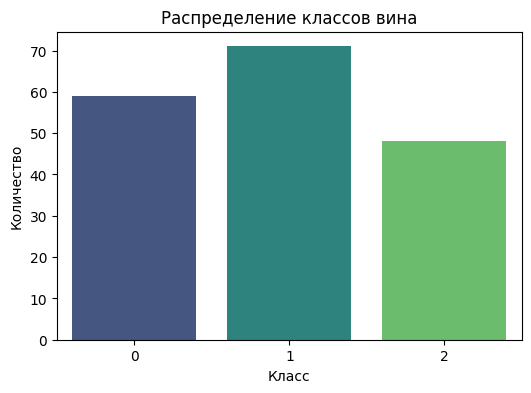

In [6]:
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df, palette='viridis')
plt.title('Распределение классов вина')
plt.xlabel('Класс')
plt.ylabel('Количество')
plt.show()

Классы распределены достаточно равномерно, нет сильного дисбаланса.

### Распределение числовых признаков

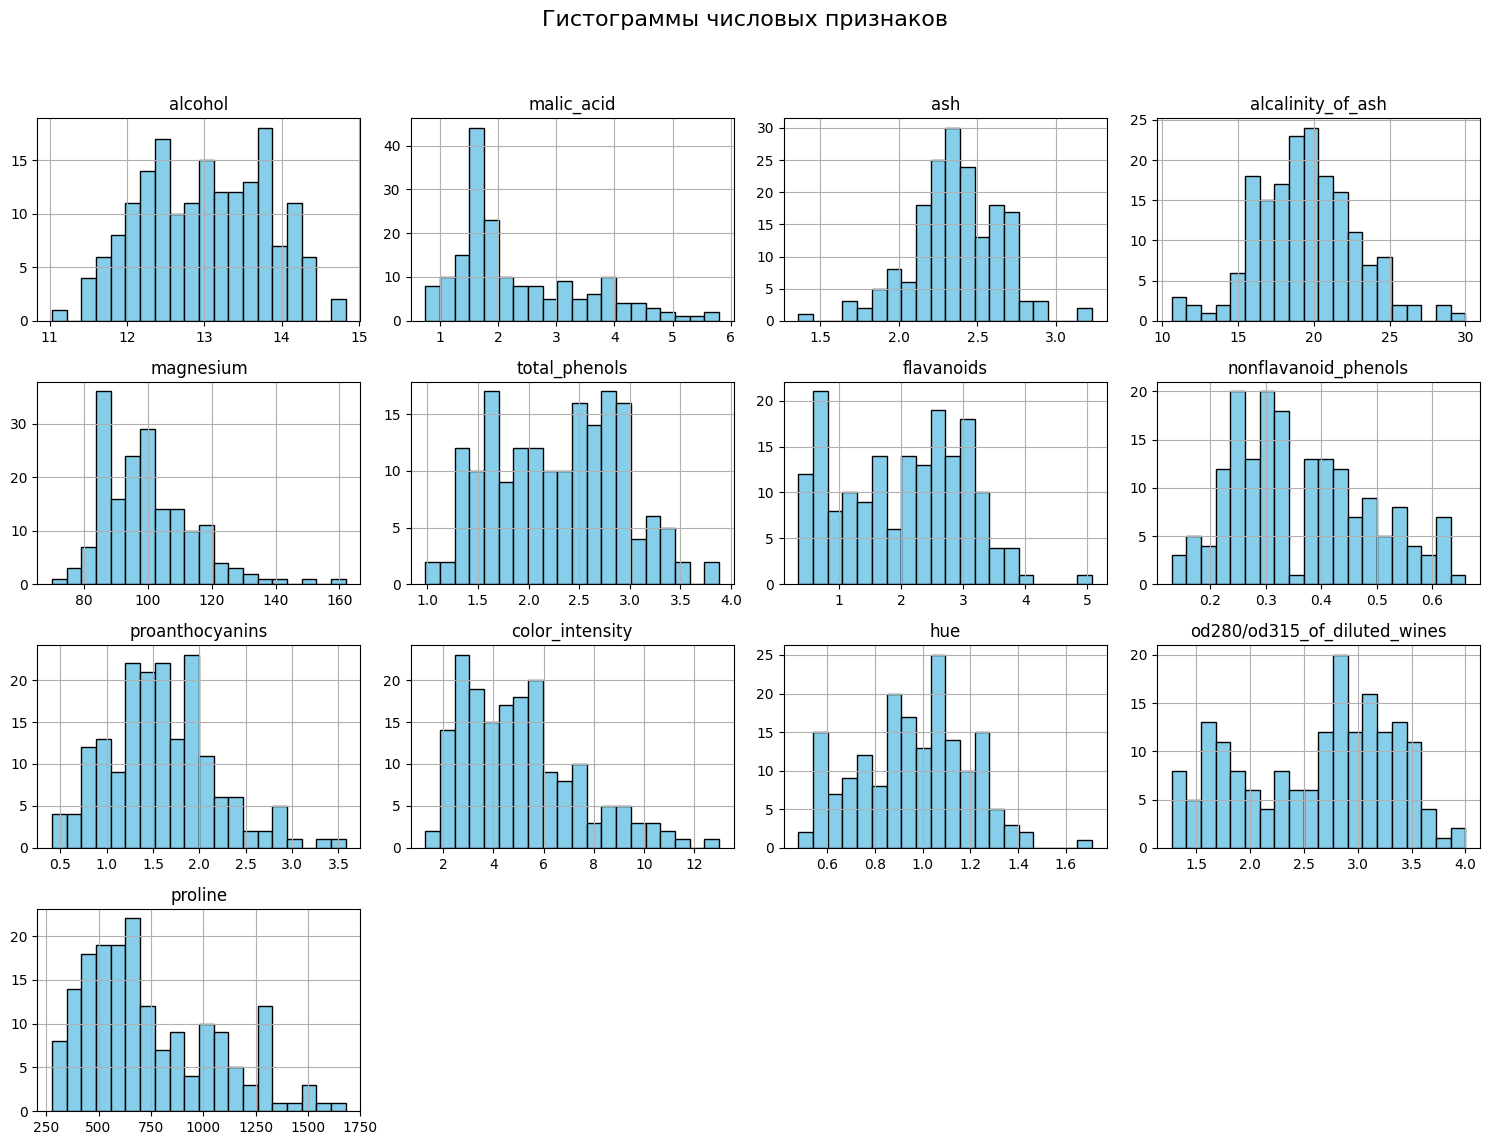

In [7]:
df.drop('target', axis=1).hist(bins=20, figsize=(15, 12), color='skyblue', edgecolor='black')
plt.suptitle('Гистограммы числовых признаков', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Некоторые признаки (например, `malic_acid`, `magnesium`) имеют смещенное (скошенное) распределение.

### Выявление выбросов (Boxplots)

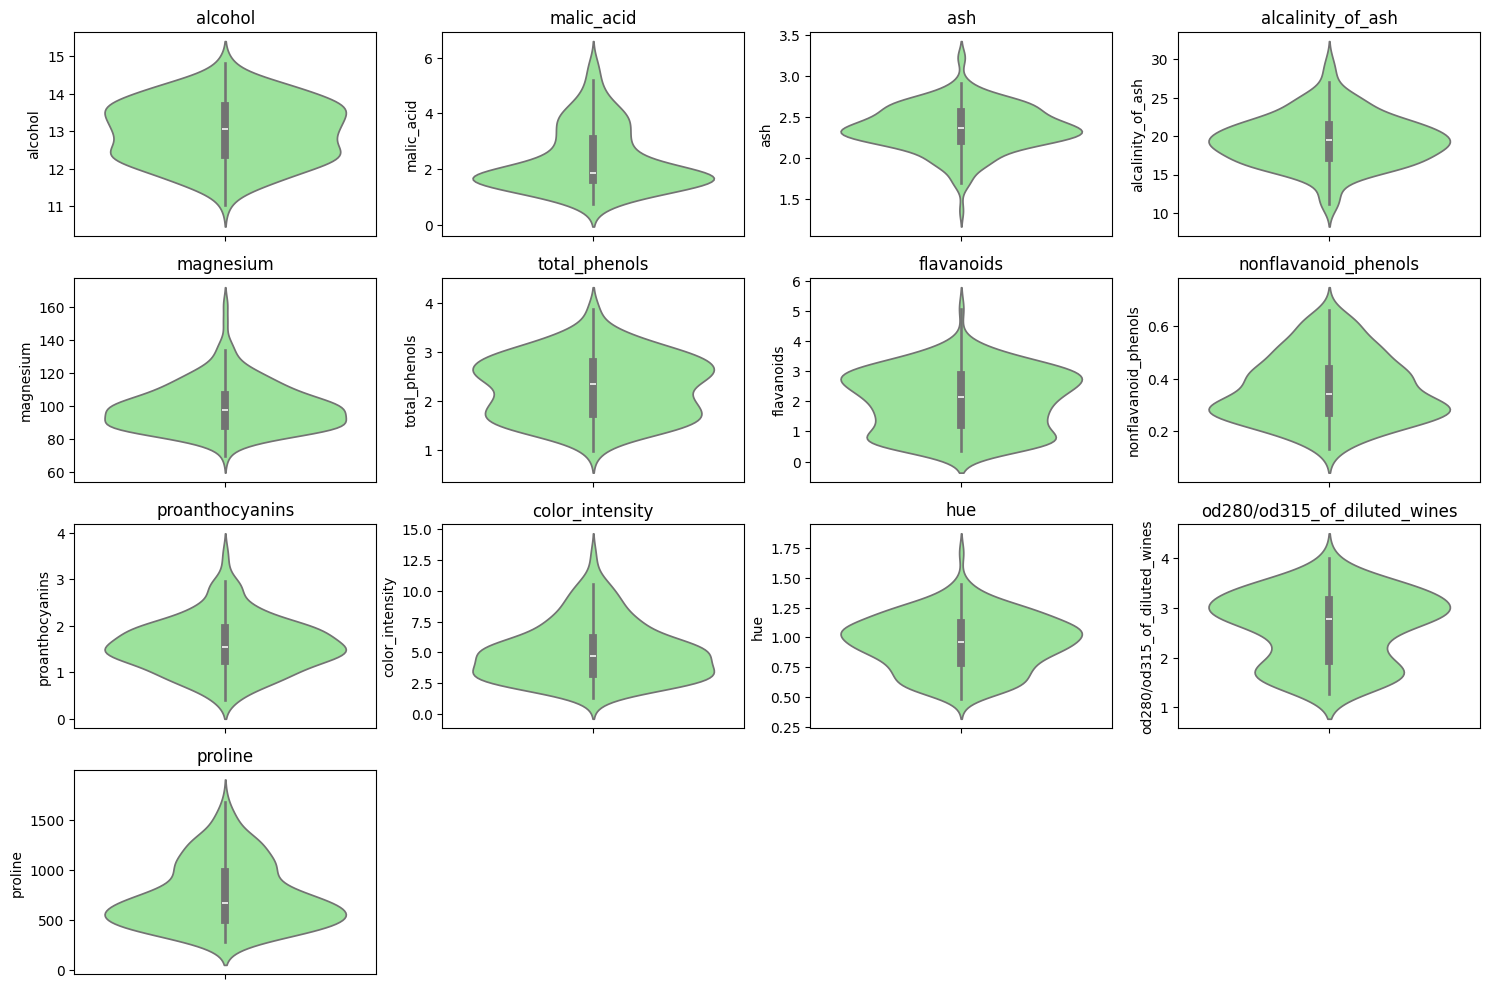

In [9]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(wine.feature_names, 1):
    plt.subplot(4, 4, i)
    sns.violinplot(y=df[col], color='lightgreen')
    plt.title(col)
plt.tight_layout()
plt.show()

В некоторых признаках (например, `malic_acid`, `ash`, `magnesium`, `color_intensity`, `proanthocyanins`) присутствуют выбросы.

### Корреляционная матрица

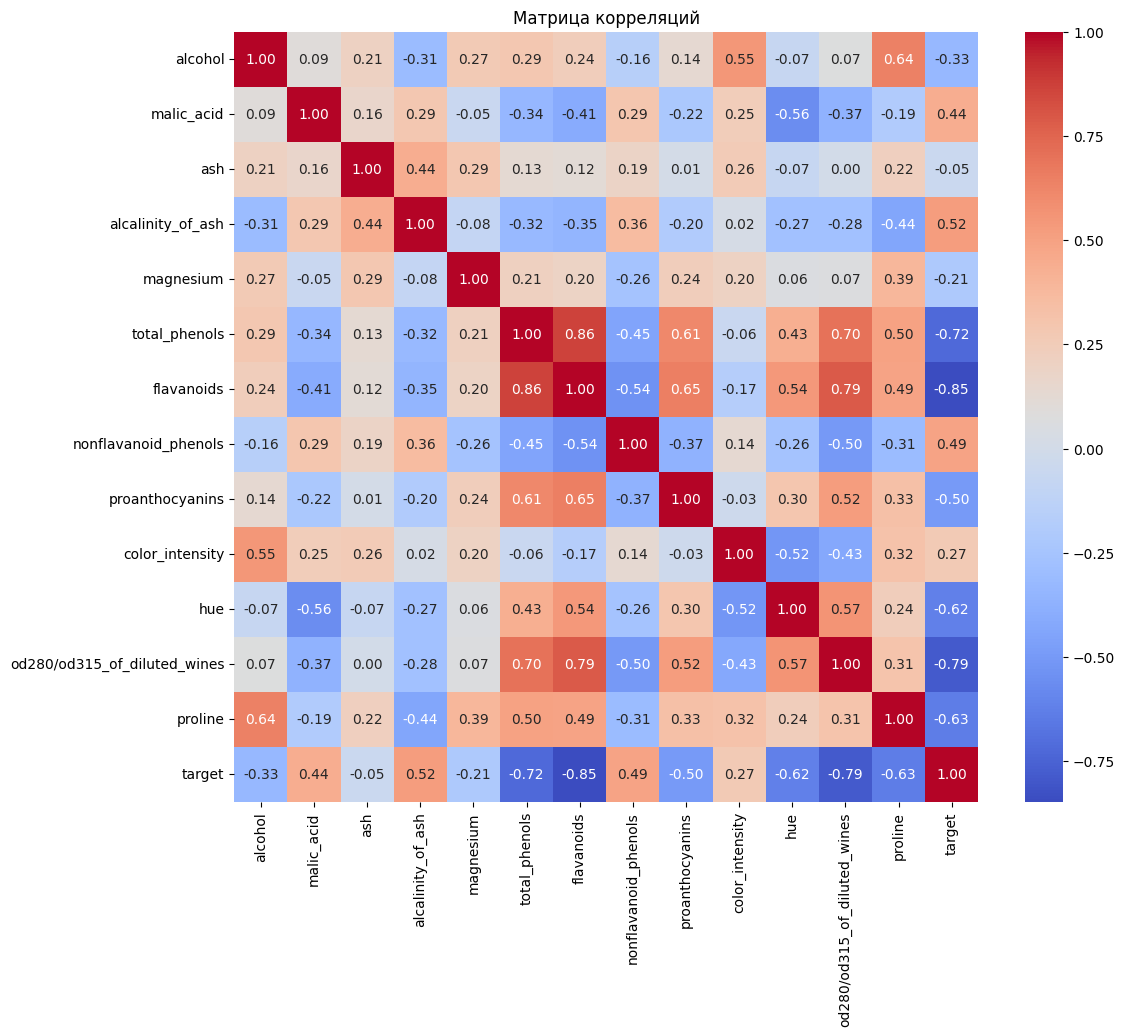

In [10]:
plt.figure(figsize=(12, 10))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Матрица корреляций')
plt.show()

Наблюдается высокая корреляция между `total_phenols` и `flavanoids` (0.86), а также сильная отрицательная корреляция `hue` и `malic_acid` (-0.56). `target` сильно отрицательно коррелирует с `flavanoids` (-0.85) и `od280/od315_of_diluted_wines` (-0.79).

Вина с более высоким содержанием алкоголя (`alcohol`) имеют бóльшую интенсивность цвета (`color_intensity`).

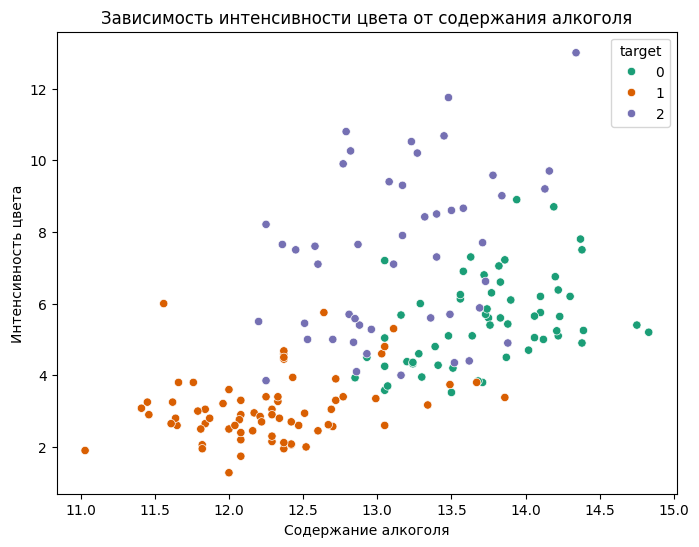

In [11]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='alcohol', y='color_intensity', hue='target', palette='Dark2', data=df)
plt.title('Зависимость интенсивности цвета от содержания алкоголя')
plt.xlabel('Содержание алкоголя')
plt.ylabel('Интенсивность цвета')
plt.show()

In [12]:
np.corrcoef(df['alcohol'], df['color_intensity'])[0, 1]

np.float64(0.5463641950837037)

Коэффициент корреляции около 0.55 указывает на умеренную положительную связь. При этом можно заметить, что класс 2 (темные точки) в основном представляет вина с высокой интенсивностью цвета и высоким содержанием алкоголя.

### Распределение признаков в зависимости от класса (Violinplot)

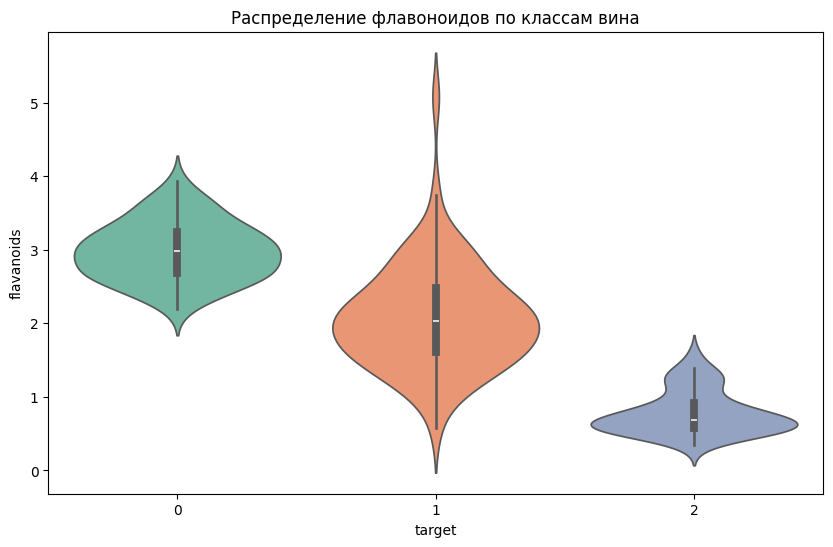

In [13]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='target', y='flavanoids', data=df, palette='Set2')
plt.title('Распределение флавоноидов по классам вина')
plt.show()

Флавоноиды (`flavanoids`) отлично разделяют классы: в классе 0 их много, в классе 1 - среднее количество, а в классе 2 - очень мало.